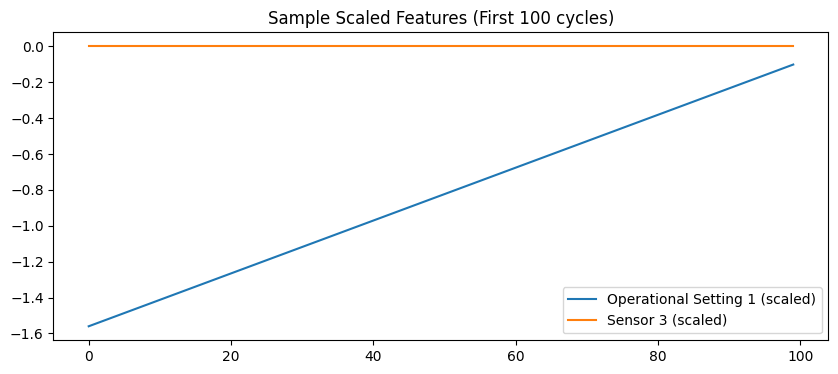

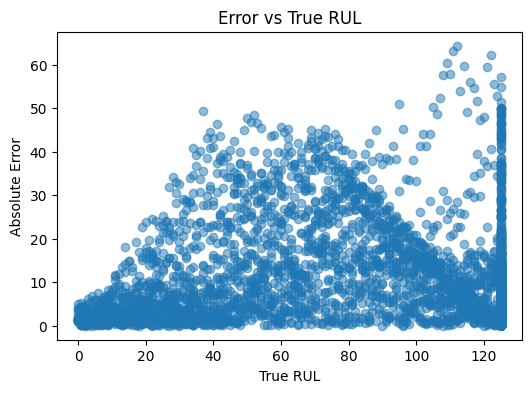

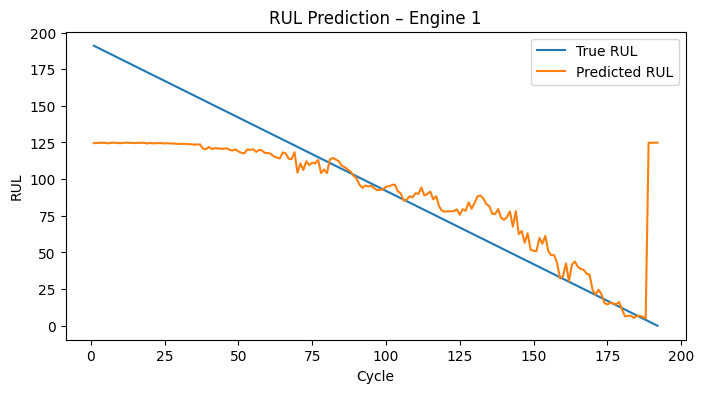

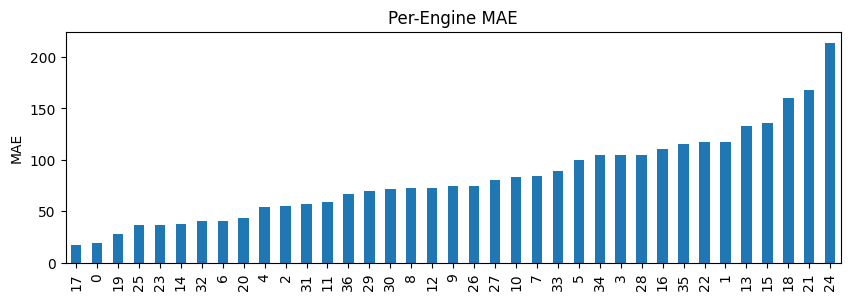

NameError: name 'y_pred' is not defined

<Figure size 500x300 with 0 Axes>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from paths import PREPROCESSED_DIR, PROCESSED_DIR

# Load processed arrays
X_scaled = np.load(PREPROCESSED_DIR / "X_train_scaled.npy")
y = np.load(PREPROCESSED_DIR / "y_train.npy")

# Load validation results
y_val = np.load(PREPROCESSED_DIR / "y_val_true.npy")
y_val_pred = np.load(PREPROCESSED_DIR / "y_val_pred.npy")
error = np.load(PREPROCESSED_DIR / "error.npy")
engine_mae = pd.Series(np.load(PREPROCESSED_DIR / "engine_mae.npy"))

# Load processed train data
df_train = pd.read_csv(PROCESSED_DIR / "train_processed.csv")

# Load test results
y_test_true = np.load(PREPROCESSED_DIR / "y_test_true.npy")
y_test_pred = np.load(PREPROCESSED_DIR / "y_test_pred.npy")
test_error = np.load(PREPROCESSED_DIR / "test_error.npy")

# If you want a specific engine for plotting
engine_id = 1
engine_data = df_train[df_train['unit_number'] == engine_id]
engine_y_true = engine_data['RUL'].values
engine_y_pred = y_val_pred[engine_data.index]

#  quick visualization of scaled features
plt.figure(figsize=(10,4))
plt.plot(X_scaled[:100, 0], label='Operational Setting 1 (scaled)')
plt.plot(X_scaled[:100, 3], label='Sensor 3 (scaled)')
plt.legend()
plt.title("Sample Scaled Features (First 100 cycles)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_val, np.abs(error), alpha=0.5)
plt.xlabel("True RUL")
plt.ylabel("Absolute Error")
plt.title("Error vs True RUL")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(engine_data['time_in_cycles'], engine_y_true, label='True RUL')
plt.plot(engine_data['time_in_cycles'], engine_y_pred, label='Predicted RUL')
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"RUL Prediction – Engine {engine_id}")
plt.legend()
plt.show()

# optional bar plot
engine_mae.sort_values().plot(kind='bar', figsize=(10,3))
plt.ylabel("MAE")
plt.title("Per-Engine MAE")
plt.show()

# residual distribution
plt.figure(figsize=(5,3))
plt.hist(y_val - y_pred, bins=40)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

df_train.filter(like='roll_slope').head()
plt.plot(engine_data['time_in_cycles'], engine_y_pred)

plt.figure(figsize=(6,4))
plt.hist(test_error, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Zero error')
plt.xlabel("Prediction Error (Predicted − True RUL)")
plt.ylabel("Frequency")
plt.title("Test Set Error Distribution")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_test_true, test_error, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs True RUL (Test Set)")
plt.show()

# using scatter plots
plt.figure(figsize=(5,5))
plt.scatter(y_test_true, y_test_pred, alpha=0.6)
plt.plot([0, 150], [0, 150], 'r--')
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL (Test)")
plt.show()
